# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [37]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate
import sklearn.discriminant_analysis as DA
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

VarNames = ["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta",
            "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R",
            "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

RawNames = ["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = list(set(VarNames[1:]).difference(RawNames))

df = pd.read_csv("SUSY-small.csv", dtype='float64', names=VarNames)
print("Total rows:", len(df))

# Split
X = df[VarNames[1:]]
y = df["signal"]

X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.2, random_state=42)

Test_sig = X_Test[y_Test == 1]
Test_bkg = X_Test[y_Test == 0]

print("Train size:", len(X_Train))
print("Test size:", len(X_Test))
print("Test signal:", len(Test_sig))
print("Test background:", len(Test_bkg))

Total rows: 500000
Train size: 400000
Test size: 100000
Test signal: 45737
Test background: 54263


In [3]:
!head -500000 /Users/reelelsadig/SUSY.csv > SUSY-small.csv

In [22]:
import os
# Check current directory
print("Current dir:", os.getcwd())

# Search for SUSY files
for root, dirs, files in os.walk(os.path.expanduser("~")):
    for f in files:
        if "SUSY" in f:
            print(os.path.join(root, f))

Current dir: /Users/reelelsadig/DATA3402.Spring.2026/Labs/Lab.8
/Users/reelelsadig/SUSY.csv
/Users/reelelsadig/DATA3402_BACKUP/DATA3402.Spring.2026/Labs/SUSY.csv.gz
/Users/reelelsadig/DATA3402_BACKUP/DATA3402.Spring.2026/Labs/SUSY-small.csv
/Users/reelelsadig/DATA3402.Spring.2026/Labs/Lab.9/SUSY.csv.gz
/Users/reelelsadig/DATA3402.Spring.2026/Labs/Lab.8/SUSY-small.csv
/Users/reelelsadig/DATA3402.Spring.2026/Labs/Lab.8/SUSY.csv


In [5]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  3228k      0 --:--:--  0:04:39 --:--:-- 4641k


In [6]:
!rm SUSY.csv

rm: SUSY.csv: No such file or directory


In [7]:
!gunzip SUSY.csv.gz

In [8]:
ls -lh

total 5135400
-rw-r--r--  1 reelelsadig  staff    13K Apr 22 14:29 Lab.8.ipynb
-rw-r--r--  1 reelelsadig  staff   228M Apr 22 14:25 SUSY-small.csv
-rw-r--r--  1 reelelsadig  staff   2.2G Apr 22 14:30 SUSY.csv


In [9]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'SUSY-small.csv', 'Lab.8.ipynb', 'SUSY.csv']


In [10]:
import sklearn
print(sklearn.__version__)

1.8.0


## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [38]:
Fisher = DA.LinearDiscriminantAnalysis()
Fisher.fit(X_Train, y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [39]:
Test_sig = X_Test[y_Test == 1]
Test_bkg = X_Test[y_Test == 0]

print("Signal test events:", len(Test_sig))
print("Background test events:", len(Test_bkg))

Signal test events: 45737
Background test events: 54263


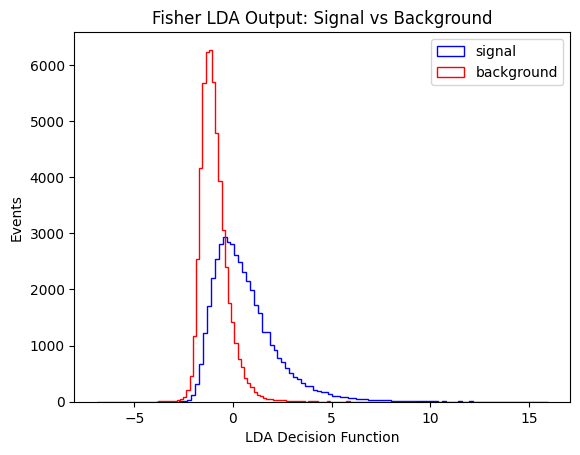

In [40]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig), bins=100,
         histtype="step", color="blue", label="signal")
plt.hist(Fisher.decision_function(Test_bkg), bins=100,
         histtype="step", color="red", label="background")
plt.legend(loc='upper right')
plt.xlabel("LDA Decision Function")
plt.ylabel("Events")
plt.title("Fisher LDA Output: Signal vs Background")
plt.show()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [34]:
print("X_Test shape:", X_Test.shape)
print("y_Test shape:", y_Test.shape)
print("y_Test unique values:", y_Test.unique())
print("Signal count:", (y_Test == 1).sum())
print("Background count:", (y_Test == 0).sum())

X_Test shape: (0, 18)
y_Test shape: (0,)
y_Test unique values: []
Signal count: 0
Background count: 0


We can train the classifier as follow:

In [24]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

In [26]:
# Rebuild Test_sig and Test_bkg from the split
Test_sig = X_Test[y_Test == 1]
Test_bkg = X_Test[y_Test == 0]

print("Signal test events:", len(Test_sig))
print("Background test events:", len(Test_bkg))

Signal test events: 0
Background test events: 0


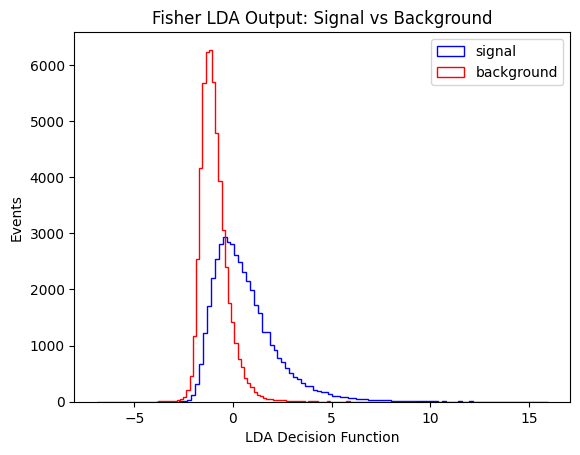

In [41]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig), bins=100, histtype="step", color="blue", label="signal")
plt.hist(Fisher.decision_function(Test_bkg), bins=100, histtype="step", color="red", label="background")
plt.legend(loc='upper right')
plt.xlabel("LDA Decision Function")
plt.ylabel("Events")
plt.title("Fisher LDA Output: Signal vs Background")
plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

In [16]:
from sklearn.metrics import roc_curve, auc

def plot_roc(classifiers_dict, X_test, y_test, title="ROC Curves"):
    """
    classifiers_dict: {"label": (classifier, X_test_subset)}
    """
    plt.figure(figsize=(8,6))
    for label, (clf, X) in classifiers_dict.items():
        fpr, tpr, _ = roc_curve(y_test, clf.decision_function(X))
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:4f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

In [21]:
N_Train = 400000

Train_Sample = df[:N_Train]
Test_Sample  = df[N_Train:]

print("Train size:", len(Train_Sample))
print("Test size:", len(Test_Sample))

Train size: 400000
Test size: 100000


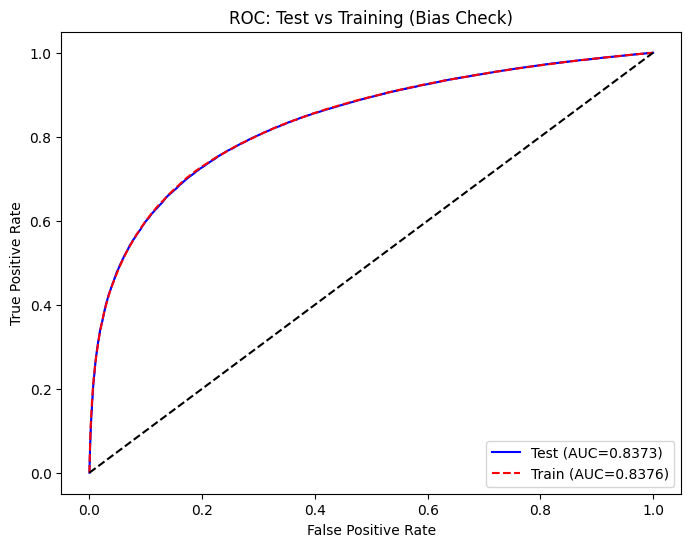

In [44]:
Fisher_all = DA.LinearDiscriminantAnalysis()
Fisher_all.fit(X_Train, y_Train)

plt.figure(figsize=(8,6))
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher_all.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)
plt.plot(fpr_test, tpr_test, color='blue', label=f"Test (AUC={auc_test:.4f})")

fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher_all.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)
plt.plot(fpr_train, tpr_train, color='red', linestyle='--', label=f"Train (AUC={auc_train:.4f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Test vs Training (Bias Check)")
plt.legend(loc="lower right")
plt.show()

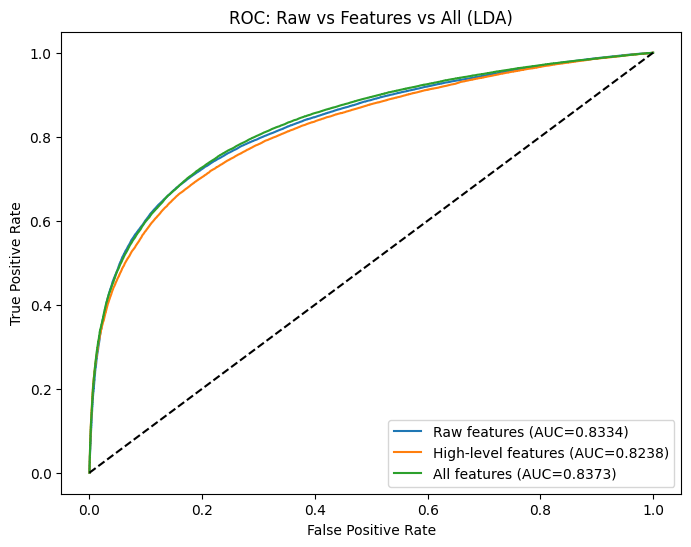

In [45]:
X_Train_raw  = X_Train[RawNames]
X_Test_raw   = X_Test[RawNames]
X_Train_feat = X_Train[FeatureNames]
X_Test_feat  = X_Test[FeatureNames]

Fisher_raw = DA.LinearDiscriminantAnalysis()
Fisher_raw.fit(X_Train_raw, y_Train)

Fisher_feat = DA.LinearDiscriminantAnalysis()
Fisher_feat.fit(X_Train_feat, y_Train)

plt.figure(figsize=(8,6))
for label, clf, X_t in [
    ("Raw features",        Fisher_raw,  X_Test_raw),
    ("High-level features", Fisher_feat, X_Test_feat),
    ("All features",        Fisher_all,  X_Test),
]:
    fpr, tpr, _ = roc_curve(y_Test, clf.decision_function(X_t))
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.4f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Raw vs Features vs All (LDA)")
plt.legend(loc="lower right")
plt.show()

In [47]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

NB = GaussianNB()
DT = DecisionTreeClassifier(max_depth=5, random_state=42)
LR = LogisticRegression(max_iter=1000, random_state=42)

NB.fit(X_Train, y_Train)
DT.fit(X_Train, y_Train)
LR.fit(X_Train, y_Train)
print("All classifiers trained.")

All classifiers trained.


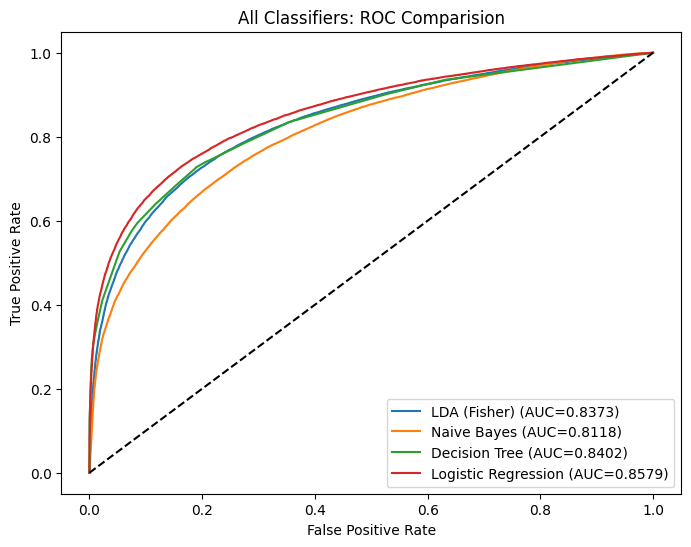

In [48]:
def compare_classifiers_roc(classifiers, X_test, y_test, title="Classifier Comparison"):
    plt.figure(figsize=(8,6))
    for name, clf in classifiers:
        if hasattr(clf, 'decision_functions'):
            scores = clf.decision_function(X_test)
        else:
            scores = clf.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.4f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

classifiers = [
    ("LDA (Fisher)",        Fisher_all),
    ("Naive Bayes",         NB),
    ("Decision Tree",       DT),
    ("Logistic Regression", LR),
]

compare_classifiers_roc(classifiers, X_Test, y_Test, "All Classifiers: ROC Comparision")
        

In [51]:
scenarios = [ 
    (10,    100),
    (100,   1000),
    (1000,  10000),
    (10000, 100000),
]

def max_significance(clf, X_test, y_test, NS, NB_count):  # fixed spelling
    if hasattr(clf, 'decision_function'):
        scores = clf.decision_function(X_test)
    else:
        scores = clf.predict_proba(X_test)[:,1]
    fpr_arr, tpr_arr, _ = roc_curve(y_test, scores)
    NS_prime = tpr_arr * NS
    NB_prime = fpr_arr * NB_count
    denom = np.sqrt(NS_prime + NB_prime)
    sig = np.where(denom > 0, NS_prime / denom, 0)
    return np.max(sig)

rows = [] 
for name, clf in classifiers:
    row = [name]
    for NS, NB_count in scenarios:
        sig = max_significance(clf, X_Test, y_Test, NS, NB_count)
        row.append(f"{sig:.3f}")
    rows.append(row)  # fixed indentation - now OUTSIDE the inner loop

headers = ["Classifier"] + [f"NS={s[0]}, NB={s[1]}" for s in scenarios]
display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))

/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)
/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)
/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)
/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)
/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)
/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:1

Classifier,"NS=10, NB=100","NS=100, NB=1000","NS=1000, NB=10000","NS=10000, NB=100000"
LDA (Fisher),1.541,4.874,15.412,48.738
Naive Bayes,1.395,4.41,13.947,44.103
Decision Tree,1.624,5.136,16.241,51.357
Logistic Regression,1.726,5.457,17.258,54.574


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [58]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             accuracy_score, confusion_matrix)
y_pred = Fisher_all.predict(X_Test)
fpr_c, tpr_c, _ = roc_curve(y_Test, Fisher_all.decision_function(X_Test))
roc_auc_val = auc(fpr_c, tpr_c)

tn, fp, fn, tp = confusion_matrix(y_Test, y_pred).ravel()
tpr_val = tp / (tp + fn)
fpr_val = fp / (fp + tn)
prec    = precision_score(y_Test, y_pred)
rec     = recall_score(y_Test, y_pred)
f1      = f1_score(y_Test, y_pred)
acc     = accuracy_score(y_Test, y_pred)

rows = []
for NS, NB_count in scenarios:
    max_sig = max_significance(Fisher_all, X_Test, y_Test, NS, NB_count)
    rows.append([
        f"NS={NS}, NB={NB_count}",
        f"{tpr_val:.4f}",
        f"{fpr_val:.4f}",
        f"{roc_auc_val:.4f}",
        f"{prec:.4f}",
        f"{rec:.4f}",
        f"{f1:.4f}",
        f"{acc:.4f}",
        f"{max_sig:.4f}",
    ])
headers = ["Scenario", "TPR","FPR","AUC","Precision","Recall","F1","Accuracy","Max Significance"]
display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))

/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)
/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)
/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)
/var/folders/j3/kyg3l4012n3_n0cftzbb2dv40000gn/T/ipykernel_28750/1509303694.py:17: RuntimeWarning: invalid value encountered in divide
  sig = np.where(denom > 0, NS_prime / denom, 0)


Scenario,TPR,FPR,AUC,Precision,Recall,F1,Accuracy,Max Significance
"NS=10, NB=100",0.5789,0.0904,0.8373,0.8437,0.5789,0.6866,0.7583,1.5412
"NS=100, NB=1000",0.5789,0.0904,0.8373,0.8437,0.5789,0.6866,0.7583,4.8738
"NS=1000, NB=10000",0.5789,0.0904,0.8373,0.8437,0.5789,0.6866,0.7583,15.4125
"NS=10000, NB=100000",0.5789,0.0904,0.8373,0.8437,0.5789,0.6866,0.7583,48.7385


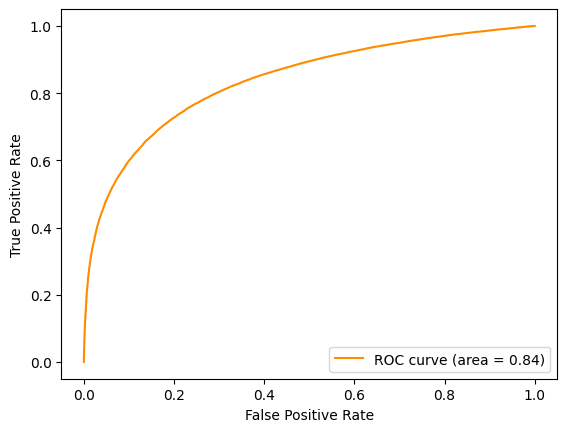

In [59]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 
